In [1]:
# ==========================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ==========================================

# Data handling
import pandas as pd
import numpy as np

# Train-test split
from sklearn.model_selection import train_test_split

# Basic models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

# Model saving
import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ==========================================
# STEP 2: LOAD PREPROCESSED DATASET
# ==========================================

# Load dataset (change path if needed)
import os
df = pd.read_csv("preprocessed_dataset.csv")

# Show first 5 rows
df.head()
df.shape

(33799, 310)

In [3]:
# ==========================================
# STEP 3: CHECK TARGET COLUMN
# ==========================================

# Check unique values in habitable_multi
print("Unique values in target:")
print(df["habitable_multi"].unique())

# Count of each class
print("\nClass distribution:")
print(df["habitable_multi"].value_counts())

Unique values in target:
[1 0 2]

Class distribution:
habitable_multi
0    24471
1     7383
2     1945
Name: count, dtype: int64


In [4]:
# ==========================================
# STEP 4: CONVERT MULTI-CLASS TO BINARY
# ==========================================

# Create new binary target column
df["habitability_binary"] = df["habitable_multi"].apply(lambda x: 1 if x in [1, 2] else 0)

# Check unique values
print("Unique values after conversion:")
print(df["habitability_binary"].unique())

# Check new class distribution
print("\nBinary class distribution:")
print(df["habitability_binary"].value_counts())

Unique values after conversion:
[1 0]

Binary class distribution:
habitability_binary
0    24471
1     9328
Name: count, dtype: int64


In [5]:
# ==========================================
# STEP 5: DEFINE FEATURES (X) AND TARGET (y)
# ==========================================

# Define target
y = df["habitability_binary"]

# Drop original target columns
X = df.drop(columns=["habitable", "habitable_multi", "habitability_binary"])

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

# Quick check
print("\nFirst 5 target values:")
print(y.head())

Feature shape: (33799, 308)
Target shape: (33799,)

First 5 target values:
0    1
1    1
2    1
3    0
4    0
Name: habitability_binary, dtype: int64


In [6]:
# ==========================================
# STEP 6: TRAIN-TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,       # 20% test
    random_state=42,     # reproducible results
    stratify=y           # maintain class balance
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training feature shape: (27039, 308)
Testing feature shape: (6760, 308)

Training target distribution:
habitability_binary
0    19577
1     7462
Name: count, dtype: int64

Testing target distribution:
habitability_binary
0    4894
1    1866
Name: count, dtype: int64


In [7]:
# ==========================================
# STEP 7: TRAIN BASELINE MODEL
# Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression

# Create model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [8]:
# ==========================================
# STEP 8: EVALUATE LOGISTIC REGRESSION
# ==========================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Make predictions
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]  # probability of class 1

# Accuracy
accuracy = accuracy_score(y_test, y_pred_log)
print("Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob_log)
print("ROC-AUC Score:", roc_auc)

Accuracy: 0.9965976331360947

Confusion Matrix:
[[4884   10]
 [  13 1853]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4894
           1       0.99      0.99      0.99      1866

    accuracy                           1.00      6760
   macro avg       1.00      1.00      1.00      6760
weighted avg       1.00      1.00      1.00      6760

ROC-AUC Score: 0.9996774053667657


In [9]:
# Check feature importance weights from logistic regression

import pandas as pd

coefficients = pd.Series(
    log_model.coef_[0],
    index=X.columns
    
).sort_values(key=abs, ascending=False)

print("Top 15 Most Influential Features:")
print(coefficients.head(15))

Top 15 Most Influential Features:
pl_rade              -15.964917
radius_score          15.883233
habitability_index    15.743665
temp_score             5.540560
pl_eqt                -5.540560
distance_score         5.447375
st_spectype_K0 III    -0.848384
st_spectype_K3 V      -0.564095
st_spectype_G0        -0.446473
st_spectype_G8 V      -0.425109
st_spectype_G5        -0.410193
st_spectype_G         -0.399724
st_spectype_K0 V      -0.395127
st_spectype_G5 V      -0.380180
st_spectype_K V       -0.325644
dtype: float64


In [10]:
# ==========================================
# REMOVE LEAKAGE FEATURES
# ==========================================

leakage_columns = [
    "habitability_index",
    "radius_score",
    "temp_score",
    "distance_score"
]

X_clean = X.drop(columns=leakage_columns, errors="ignore")

print("New feature shape:", X_clean.shape)

New feature shape: (33799, 304)


In [11]:
# ==========================================
# STEP 9: RETRAIN LOGISTIC REGRESSION
# (Without leakage features)
# ==========================================

log_model_clean = LogisticRegression(max_iter=1000)

# Train on cleaned features
log_model_clean.fit(X_train[X_clean.columns], y_train)

print("Clean Logistic Regression training completed.")

Clean Logistic Regression training completed.


In [12]:
# ==========================================
# STEP 10: EVALUATE CLEAN MODEL
# ==========================================

y_pred_clean = log_model_clean.predict(X_test[X_clean.columns])
y_prob_clean = log_model_clean.predict_proba(X_test[X_clean.columns])[:, 1]

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Logistic Regression metrics
acc_log = accuracy_score(y_test, y_pred_log)
f1_log = classification_report(y_test, y_pred_log, output_dict=True)["1"]["f1-score"]

print("Logistic Regression Accuracy:", acc_log)
print("Logistic Regression F1:", f1_log)

print("ROC-AUC:", roc_auc_score(y_test, y_prob_clean))

Logistic Regression Accuracy: 0.9965976331360947
Logistic Regression F1: 0.9938321265754894
ROC-AUC: 0.9920159470813399


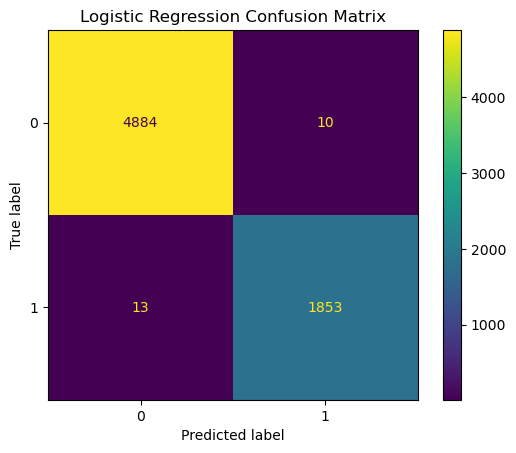

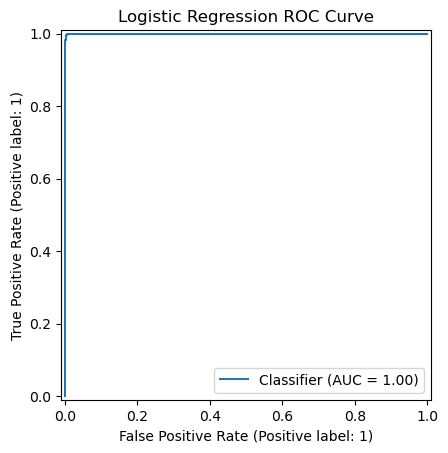

In [14]:
# ==========================================
# LOGISTIC REGRESSION CONFUSION MATRIX
# ==========================================
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

cm_log = confusion_matrix(y_test, y_pred_log)

ConfusionMatrixDisplay(cm_log).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()
# ==========================================
# LOGISTIC REGRESSION ROC CURVE
# ==========================================

y_prob_log = log_model.predict_proba(X_test)[:,1]

RocCurveDisplay.from_predictions(y_test, y_prob_log)

plt.title("Logistic Regression ROC Curve")
plt.show()

In [15]:
# ==========================================
# STEP 11: TRAIN RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train[X_clean.columns], y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [16]:
# ==========================================
# STEP 12: EVALUATE RANDOM FOREST
# ==========================================

y_pred_rf = rf_model.predict(X_test[X_clean.columns])
y_prob_rf = rf_model.predict_proba(X_test[X_clean.columns])[:, 1]

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Random Forest metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = classification_report(y_test, y_pred_rf, output_dict=True)["1"]["f1-score"]

print("Random Forest Accuracy:", acc_rf)
print("Random Forest F1:", f1_rf)
# ==========================================
# RANDOM FOREST ROC AUC
# ==========================================

roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_rf)

Random Forest Accuracy: 0.9849112426035503
Random Forest F1: 0.972551130247578
Random Forest ROC-AUC: 0.9990961108621752


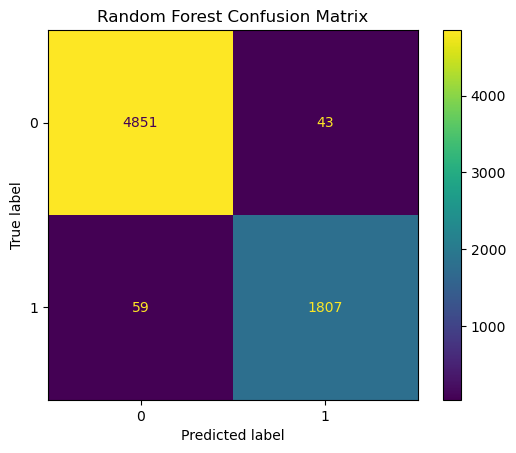

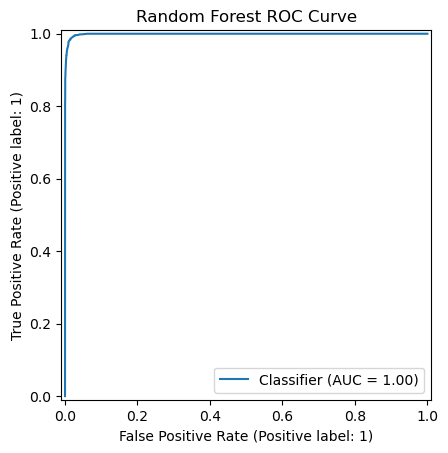

In [17]:
# ==========================================
# RANDOM FOREST CONFUSION MATRIX
# ==========================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()
# ==========================================
# RANDOM FOREST ROC CURVE
# ==========================================

from sklearn.metrics import RocCurveDisplay

y_prob_rf = rf_model.predict_proba(X_test[X_clean.columns])[:,1]

RocCurveDisplay.from_predictions(y_test, y_prob_rf)

plt.title("Random Forest ROC Curve")
plt.show()

Top 15 Important Features:
pl_rade                        0.386905
pl_eqt                         0.192909
pl_orbsmax                     0.088133
orbital_stability_factor       0.064775
pl_orbper                      0.055481
st_teff                        0.037419
stellar_compatibility_index    0.033549
stellar_temp_score             0.031573
st_met                         0.026014
st_lum                         0.023030
stellar_lum_score              0.020270
pl_bmasse                      0.016987
pl_dens                        0.009272
st_spectype_G0 V               0.002712
st_spectype_M0 V               0.000553
dtype: float64


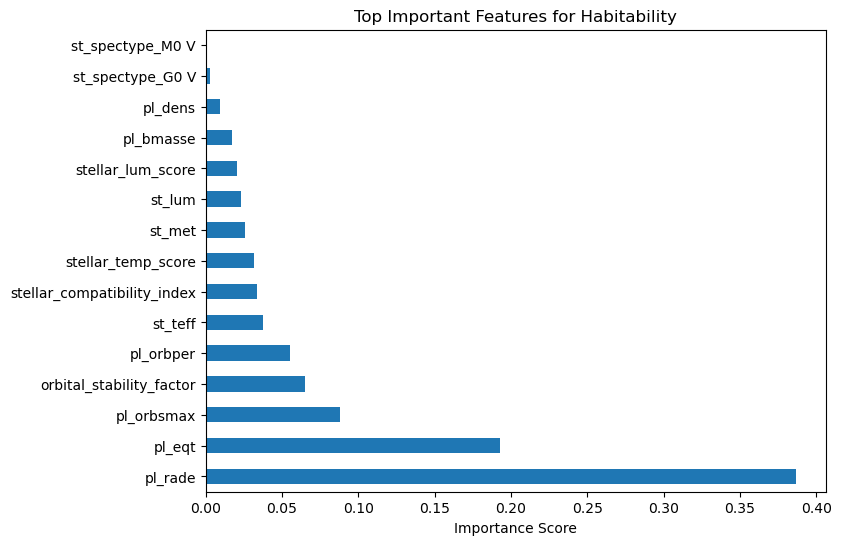

In [18]:
# ==========================================
# STEP 13: GET FEATURE IMPORTANCE
# ==========================================

import pandas as pd

# Get feature importance
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_clean.columns
).sort_values(ascending=False)

# Show top 15 features
print("Top 15 Important Features:")
print(feature_importance.head(15))
# ==========================================
# FEATURE IMPORTANCE PLOT
# ==========================================

import matplotlib.pyplot as plt

feature_importance.sort_values(ascending=False).head(15).plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top Important Features for Habitability")
plt.xlabel("Importance Score")
plt.show()

In [19]:
# ==========================================
# CREATE MODELS DIRECTORY IF NOT EXISTS
# ==========================================

import os

os.makedirs("models", exist_ok=True)

print("Models folder ready.")

Models folder ready.


In [33]:
# ==========================================
# SAVE RANDOM FOREST MODEL
# ==========================================
import joblib
joblib.dump(rf_model, "models/random_forest.pkl")

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [ ]:
import xgboost
print("XGBoost is installed")

In [21]:
# ==========================================
# STEP: TRAIN XGBOOST
# ==========================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,      # number of trees
    max_depth=6,           # tree depth
    learning_rate=0.1,     # step size
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train[X_clean.columns], y_train)

print("XGBoost training completed.")

XGBoost training completed.


In [22]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=3,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best F1 Score:", random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best F1 Score: 0.996654352662142


In [23]:
# ==========================================
# EVALUATE XGBOOST
# ==========================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred_xgb = xgb_model.predict(X_test[X_clean.columns])
y_prob_xgb = xgb_model.predict_proba(X_test[X_clean.columns])[:, 1]
# XGBoost metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)["1"]["f1-score"]

print("XGBoost Accuracy:", acc_xgb)
print("XGBoost F1:", f1_xgb)


print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Accuracy: 0.9970414201183432
XGBoost F1: 0.9946351931330472
ROC-AUC: 0.9999537899065768


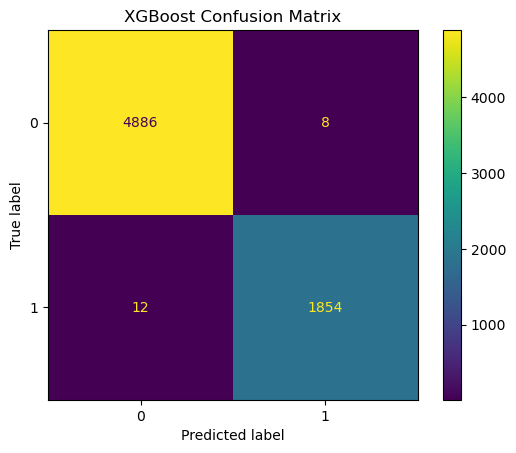

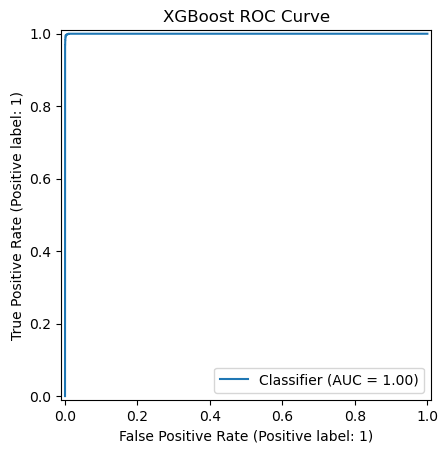

In [24]:
# ==========================================
# XGBOOST CONFUSION MATRIX
# ==========================================

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

ConfusionMatrixDisplay(cm_xgb).plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

# ==========================================
# XGBOOST ROC CURVE
# ==========================================

y_prob_xgb = xgb_model.predict_proba(X_test[X_clean.columns])[:,1]

RocCurveDisplay.from_predictions(y_test, y_prob_xgb)

plt.title("XGBoost ROC Curve")
plt.show()

In [25]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    xgb_model,
    X_clean,
    y,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Average F1-score:", np.mean(cv_scores))

Cross-validation F1 scores: [0.97254488 0.99197432 0.99118825 0.99301826 0.98979044]
Average F1-score: 0.9877032285135309


In [26]:
# ==========================================
# GENERATE HABITABILITY PROBABILITY
# ==========================================

df["habitability_probability"] = xgb_model.predict_proba(X_clean)[:,1]

df[["habitability_probability"]].head()

,habitability_probability
0,0.998833
1,0.998710
2,0.998517
3,0.000406
4,0.000511


In [27]:
# ==========================================
# RANK EXOPLANETS BY HABITABILITY
# ==========================================

df_ranked = df.sort_values(
    by="habitability_probability",
    ascending=False
)

df_ranked.head(20)

,pl_rade,pl_bmasse,pl_orbper,pl_orbsmax,pl_eqt,pl_dens,st_teff,st_lum,st_met,temp_score,...,st_spectype_M8.5,st_spectype_M9,st_spectype_M9-L1,st_spectype_T8.5,st_spectype_WD,st_spectype_m3 V,habitable,habitable_multi,habitability_binary,habitability_probability
23507,-0.673348,-0.186677,0.660442,0.874564,-2.198390,-0.120056,0.200624,0.057999,-1.519220,2.198390,...,False,False,False,False,False,False,36.041109,2,1,0.999998
23506,-0.661615,-0.186677,0.660432,0.868543,-2.198390,-0.120056,0.199199,0.057999,-1.652161,2.198390,...,False,False,False,False,False,False,36.041109,2,1,0.999998
8485,-0.567752,-0.186677,0.231167,0.404552,-2.150224,-0.120056,0.341744,0.057999,-2.715691,2.150224,...,False,False,False,False,False,False,36.041109,2,1,0.999998
25632,-0.573619,-0.186677,0.387907,0.540776,-2.198390,-0.120056,-0.730201,0.057999,-2.449808,2.198390,...,False,False,False,False,False,False,36.041109,2,1,0.999998
9122,-0.585352,-0.186677,0.010208,0.166724,-1.949534,-0.120056,0.301832,0.057999,0.076075,1.949534,...,False,False,False,False,False,False,-0.027746,2,1,0.999998
10623,-0.579485,-0.186677,0.023965,0.178766,-1.712719,-0.120056,0.702386,0.057999,-1.652161,1.712719,...,False,False,False,False,False,False,-0.027746,2,1,0.999998
26388,-0.482689,-0.186677,0.330381,0.519076,-2.198390,-0.120056,0.283301,0.057999,-2.050985,2.198390,...,False,False,False,False,False,False,-0.027746,2,1,0.999997
26390,-0.485622,-0.186677,0.330382,0.519076,-2.198390,-0.120056,0.283301,0.057999,-2.050985,2.198390,...,False,False,False,False,False,False,-0.027746,2,1,0.999997
25622,-0.541353,-0.186677,0.052017,0.150793,-2.198390,-0.120056,-0.899831,0.057999,0.054804,2.198390,...,False,False,False,False,False,False,-0.027746,2,1,0.999997
22290,-0.623484,-0.186677,-0.159370,-0.159036,-1.752857,-0.120056,-1.050930,0.057999,0.054804,1.752857,...,False,False,False,False,False,False,-0.027746,2,1,0.999997


In [30]:
# Training accuracy
print("Training Accuracy (XGB):", accuracy_score(y_train, xgb_model.predict(X_train[X_clean.columns])))

# Testing accuracy
print("Testing Accuracy (XGB):", accuracy_score(y_test, y_pred_xgb))

Training Accuracy (XGB): 1.0
Testing Accuracy (XGB): 0.9970414201183432


In [29]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy":[acc_log, acc_rf, acc_xgb],
    "F1":[f1_log, f1_rf, f1_xgb]
})

print(results)

                 Model  Accuracy        F1
0  Logistic Regression  0.996598  0.993832
1        Random Forest  0.984911  0.972551
2              XGBoost  0.997041  0.994635


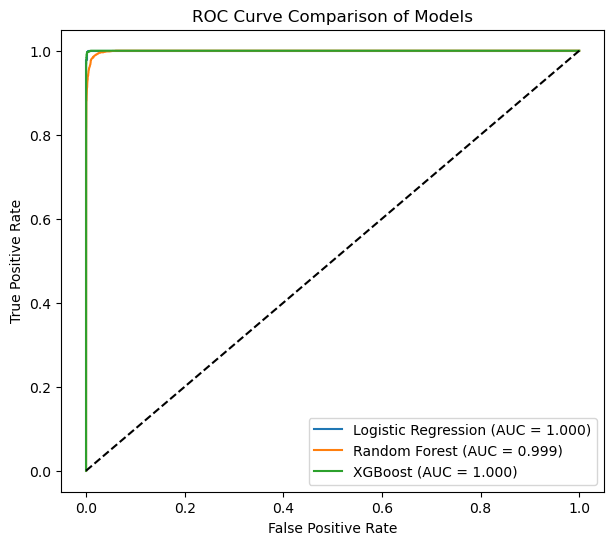

In [28]:
# ==========================================
# FINAL MODEL ROC COMPARISON
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(7,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

plt.plot([0,1],[0,1],'k--')  # Random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Models")

plt.legend()
plt.show()

In [31]:
import joblib
joblib.dump(xgb_model, "models/xgboost.pkl")

['models/xgboost.pkl']

In [32]:
df_ranked.to_csv("habitability_ranked.csv", index=False)